---
title: "Checking Staffing Feasibility with Routing - A Single Staff Member"
image: image.png
toc: true
execute: 
  enabled: false
---

Lokigi also provides some routing helpers. 

It's important to consider lokigi's role in routing. It's **not** designed for use as a daily operational tool for routing problems. 

Where it is intended to sit is as a helper for business cases and higher-level staffing decisions. Given a historic demand and 

In [2]:
from lokigi.routing import RoutingProblem

problem = RoutingProblem()

problem.add_region_geometry_layer(
    "../../../sample_data/Lower_layer_Super_Output_Areas_December_2021_Boundaries_EW_BSC_V4_6453788336260919790.gpkg",
    common_col="LSOA21NM"
    )

Just like with our SiteProblem, we can inspect this. 

In [3]:
problem.show_region_geometry_layer()

,LSOA21CD,LSOA21NM,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,GlobalID,geometry
0,E01000001,City of London 001A,,532123,181632,51.518169,-0.097150,{3478C558-3297-4E2B-979E-E29DD9FF3BF5},"MULTIPOLYGON (((532282.63 181906.496, 532104.8..."
1,E01000002,City of London 001B,,532480,181715,51.518829,-0.091970,{F2072109-B1AE-426C-B166-083CC32F1789},"MULTIPOLYGON (((532746.813 181786.891, 532419...."
2,E01000003,City of London 001C,,532239,182033,51.521740,-0.095330,{A9009C33-9B6B-4230-BA62-FC3264806DE4},"MULTIPOLYGON (((532293.112 182068.355, 532135...."
3,E01000005,City of London 001E,,533581,181283,51.514690,-0.076280,{86AEE0AA-079F-4F92-8F9D-5773824F4945},"MULTIPOLYGON (((533604.265 181418.14, 533499.0..."
4,E01000006,Barking and Dagenham 016A,,544994,184274,51.538750,0.089317,{C33F1F5B-6B15-47A1-B046-B6A148A9F6D3},"MULTIPOLYGON (((545271.849 184184.053, 544787...."
...,...,...,...,...,...,...,...,...,...
35667,W01002036,Vale of Glamorgan 005G,Bro Morgannwg 005G,317939,172435,51.444939,-3.182180,{F79ED9C6-8220-49D9-9A69-E80E9F0007CB},"MULTIPOLYGON (((318294.782 172660.827, 317531...."
35668,W01002037,Vale of Glamorgan 005H,Bro Morgannwg 005H,318527,172406,51.444759,-3.173710,{FDD8E9DC-8504-4955-AA8D-E4CFF563ED76},"MULTIPOLYGON (((319033.579 172604.209, 318294...."
35669,W01002038,Vale of Glamorgan 014G,Bro Morgannwg 014G,306491,167360,51.397541,-3.345520,{7B56D7B1-48E6-4883-A46E-3BD00345BC8C},"MULTIPOLYGON (((306621.637 166496.871, 307760 ..."
35670,W01002039,Vale of Glamorgan 014H,Bro Morgannwg 014H,306564,166023,51.385529,-3.344120,{36D00276-9970-4F4B-9322-5B89FDACF0C3},"MULTIPOLYGON (((307138.404 165707.568, 306621...."


<Axes: >

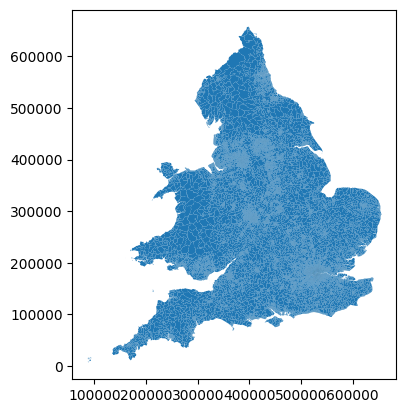

In [4]:
problem.plot_region_geometry_layer(edgecolor="white")

It looks like we've got the whole of the UK. We could leave it like this, but as we know we're definitely only working with Devon, we could also opt to overwrite it with Devon only. 

In [5]:
problem.region_geometry_layer = problem.region_geometry_layer[problem.region_geometry_layer["LSOA21NM"].str.contains(
    "Devon|Torbay|South Hams|Exeter|Torridge|Teignbridge|Plymouth"
    )]

<Axes: >

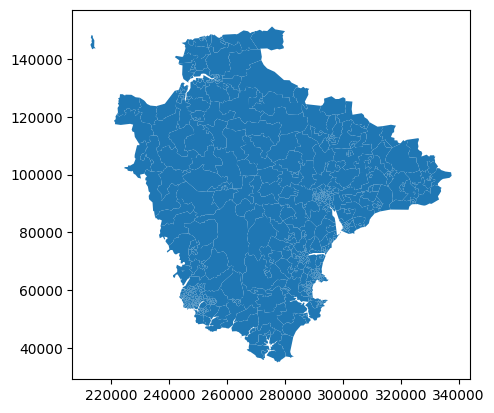

In [6]:
problem.plot_region_geometry_layer()

We've got our region data at LSOA level, but for our nurse travel, we're going to be working at the level of postcodes. 

So let's add in a lookup. 

In [7]:
problem.add_geo_lookup(
    "../../../sample_data/PCD_LSOA21_lookup_devon.csv",
    common_col="LSOA21NM",
    rename={"lsoa21nm":"LSOA21NM", "pcd7":"PCD7"}
    )

In [8]:
problem.show_geo_lookup()

,PCD7,LSOA21NM
0,DT7 3EG,East Devon 007E
1,DT7 3NF,East Devon 007E
2,DT7 3RA,East Devon 007E
3,DT7 3RB,East Devon 007E
4,DT7 3RD,East Devon 007E
...,...,...
54692,TQ9 9TJ,South Hams 003C
54693,TQ9 9TL,South Hams 003C
54694,TQ9 9TP,South Hams 003C
54695,TQ9 9TQ,South Hams 003C


Finally, rather than using a travel matrix, we're going to look up routes on the fly using the **valhalla** package. 

If we want to do fine-grained routing, using travel matrices becomes prohibitively large even when covering a fairly small area. For example, a postcode-to-postcode matrix covering Torquay only would contain over 10 million combinations. Expand that to the whole of Devon, and we're up to over 90 million. 

So lokigi tries its best to intelligently request routes as and when it needs them, caching them to prevent things being requested repeatedly. 

:::{.callout-note}
In Python 3.12+, valhalla can be accessed fully through Python. 

Unlike r5py, it doesn't require Java, so is easier to get installed in locked-down environments. It is also a bit more geared up for car travel times, which is the most likely thing we are going to want to use when we are doing point-to-point routing like this. While some argue r5py is better for non-car travel, valhalla will likely do well enough for most use cases. Routing support for r5py may be added in the future. 
:::

What we need to do is let lokigi know where the required file for valhalla is. 

We can point it towards an `.osm.pbf` file - open street map data. We can obtain this from sites like geofabrik: [https://download.geofabrik.de/](https://download.geofabrik.de/)

Alternatively, if you are an advanced user, you can provide it with the path to a pre-created `.json` file in the format valhalla expects. You may prefer to do this if you are incorporating additional data files like public transport route files. 

If you are just interested in simple car routing, then passing in the `.osm.pbf` file will be sufficient (though you may wish to explore the approaches to modifying car speeds in [this section of the documentation](../../other/modifying_osm_max_speeds/index.ipynb)).

In [9]:
# problem.add_routing_data("../../datasets/devon-260422-combined-modified.osm.pbf")
problem.add_routing_data("../../datasets/devon-260422_valhalla-combined-modified.json")

## Adding Resource Attributes

### Resource Start/End Point 

We're going to first explore a single resource and its ability to route between several known demand points. 

First, we need to set up the starting location of our resource. 

When we move to multiple resources, we'll be able to either give each a unique starting location (for example, if they all start and end from their own home), or all can have the same starting location (e.g. if they all start and end from a clinic or hub).

In this instance, we'll assume we have a single nurse who starts from their own home. 

In [ ]:
problem.add_resources_same_starts(
    1,
    starting_coordinates=(-3.3999133784101137, 50.854963288045866),
    max_shift_duration_mins=60*8,
    shift_duration_flex_mins=0,
    lunch_duration_mins=30
    )

In [15]:
problem.show_resources()

,label,return_to_start,x,y,geometry
0,Resource_1,True,-3.399913,50.854963,POINT (-3.4 50.855)


In [17]:
problem.plot_resources(interactive=True)

Vidigi supports two ways of passing in demand. 

- You can pass in the exact demand for a single day of activity
    - You can also pass in daily demand across a wider sample of days and the optimisation will run individually for each day, but give you a better idea of whether the service will copy all the time, some of the time, or never 
    - This can either be passed in as a single long dataframe with a date or day column, or as a list of dataframes which will each be assumed to cover a single day
    - As each day is independent, lokigi will attempt to run these analyses in parallel using multiple processor cores, minimizing the linear processing time
- (COMING SOON) You can pass in demand at a given scale (e.g. year), and lokigi will then sample that demand (assuming a particular distribution, defaulting to the normal distribution)
    - If you don't have historic data, you may wish to think about defensible ways to estimate per-locale demand. For example, taking an age-weighted population data file and estimating the total number of cases in each region, which can then be used to power the stochastic sampling approach. 

Lokigi expects the demand to have the following columns:
- location (as either exact coordinates, postcodes, LSOAs, or any other geometry)
    - If not passing exact coordinates, you need to add a centroid lookup file to your problem class [TO WRITE HOW THIS GETS USED!!]
- a count of daily incidents in that location
    - if not passed, this will be assumed to be 1 for all instances (which is likely to be desired behaviour if you are passing in exact locations). 

- A column with exact durations for different appointments. 
    - Alternatively, you can pass in a sim-tools distribution object, which will then be used to sample realistic appointment durations [WRITE THIS FEATURE...]

[ADD option for random delay chance? How to make accurate? Separate for the appointment and the journey?]

In [ ]:
problem.add_visits("../../../sample_data/sample_daily_routing_demand_reduced.csv")

In [ ]:
problem.show_visits()

In [ ]:
problem.plot_visits()

## Routing with a single nurse and exact demand

Now we have our demand, we can ask lokigi to find a route. 